**SOLUCIÓN COMPLETA DEL CASO**

**ETAPA 1 — CONFIGURACIÓN DEL ENTORNO**

In [ ]:
# =========================================
# ETAPA 1 - CONFIGURACIÓN DEL ENTORNO
# =========================================

from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

# Ruta del dataset
ruta_dataset = "/content/drive/MyDrive/Informatica/dataset_set_A_aguas_residuales.xlsx"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**ETAPA 2 — IMPORTACIÓN DE LIBRERÍAS**

In [ ]:
# =========================================
# ETAPA 2 - IMPORTACIÓN DE LIBRERÍAS
# =========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
from joblib import dump, load

# Configuración visual
sns.set(style="whitegrid")

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (10, 6)

**ETAPA 3 — CARGA Y EXPLORACIÓN INICIAL DEL DATASET**

In [ ]:
# =========================================
# ETAPA 3 - CARGA Y EXPLORACIÓN DEL DATASET
# =========================================

# Cargar dataset
df = pd.read_excel(ruta_dataset)

# Visualización inicial
print("Primeros registros del dataset:")
display(df.head())

# Información general
print("\nInformación general del dataset:")
df.info()

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(df.describe())

# Dimensiones del dataset
print(f"\nCantidad de filas y columnas: {df.shape}")

Primeros registros del dataset:


,fecha_registro,planta,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L,cumplimiento_norma
0,2025-08-17,Planta Sur,6562,271,324,7.12,1261.1,440.3,40.0,0
1,2025-09-07,Planta Sur,5336,322,230,7.01,1629.3,561.2,26.8,1
2,2025-07-26,Planta Norte,5755,318,282,6.79,1469.2,441.6,45.2,0
3,2025-10-27,Planta Centro,6840,216,167,7.01,1764.8,560.0,38.0,0
4,2025-09-06,Planta Centro,6803,326,200,7.55,1409.3,654.0,32.1,0



Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha_registro        200 non-null    object 
 1   planta                200 non-null    object 
 2   caudal_entrada_m3_d   200 non-null    int64  
 3   DBO_entrada_mg_L      200 non-null    int64  
 4   SST_entrada_mg_L      200 non-null    int64  
 5   pH_entrada            200 non-null    float64
 6   energia_aeracion_kWh  200 non-null    float64
 7   lodos_generados_kg_d  200 non-null    float64
 8   DBO_salida_mg_L       200 non-null    float64
 9   cumplimiento_norma    200 non-null    int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 15.8+ KB

Estadísticas descriptivas:


,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L,cumplimiento_norma
count,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.00000
mean,5059.285000,280.145000,232.670000,7.16240,1256.394500,428.795500,36.177500,0.22500
std,1410.971334,75.566497,64.289398,0.42381,420.146335,144.744253,13.259427,0.41863
min,1500.000000,90.000000,70.000000,6.18000,279.700000,113.700000,10.200000,0.00000
25%,4193.750000,223.000000,192.500000,6.84750,950.650000,321.175000,26.075000,0.00000
50%,5092.500000,284.000000,233.500000,7.14000,1212.850000,429.700000,35.150000,0.00000
75%,6037.750000,333.250000,277.500000,7.45250,1516.750000,524.825000,45.825000,0.00000
max,9205.000000,481.000000,391.000000,8.27000,2434.000000,971.700000,79.000000,1.00000



Cantidad de filas y columnas: (200, 10)


**ETAPA 4 — LIMPIEZA Y CALIDAD DE DATOS**

Valores nulos por columna:


,0
fecha_registro,0
planta,0
caudal_entrada_m3_d,0
DBO_entrada_mg_L,0
SST_entrada_mg_L,0
pH_entrada,0
energia_aeracion_kWh,0
lodos_generados_kg_d,0
DBO_salida_mg_L,0
cumplimiento_norma,0



Cantidad de registros duplicados: 0

Tipos de datos:


,0
fecha_registro,datetime64[ns]
planta,object
caudal_entrada_m3_d,int64
DBO_entrada_mg_L,int64
SST_entrada_mg_L,int64
pH_entrada,float64
energia_aeracion_kWh,float64
lodos_generados_kg_d,float64
DBO_salida_mg_L,float64
cumplimiento_norma,int64


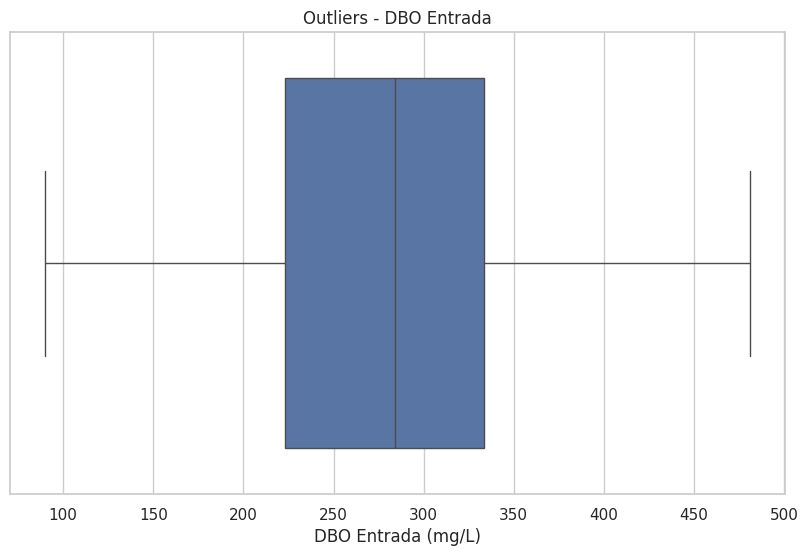

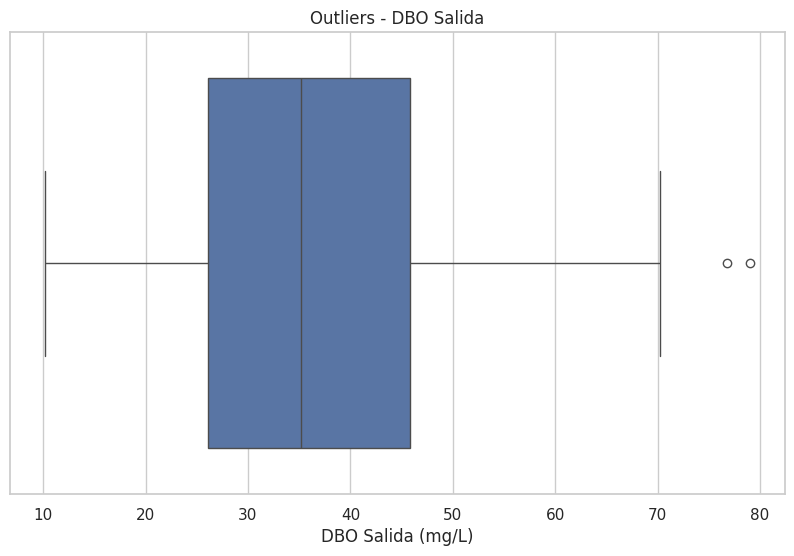

In [ ]:
# =========================================
# ETAPA 4 - LIMPIEZA Y CALIDAD DE DATOS
# =========================================

# Conversión de fecha
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'])

# Verificación de valores nulos
print("Valores nulos por columna:")
display(df.isnull().sum())

# Verificación de duplicados
duplicados = df.duplicated().sum()

print(f"\nCantidad de registros duplicados: {duplicados}")

# Verificación de tipos de datos
print("\nTipos de datos:")
display(df.dtypes)

# =========================================
# DETECCIÓN DE OUTLIERS
# =========================================

# Outliers DBO entrada
plt.figure()

sns.boxplot(
    x=df['DBO_entrada_mg_L']
)

plt.title('Outliers - DBO Entrada')
plt.xlabel('DBO Entrada (mg/L)')

plt.show()

# Outliers DBO salida
plt.figure()

sns.boxplot(
    x=df['DBO_salida_mg_L']
)

plt.title('Outliers - DBO Salida')
plt.xlabel('DBO Salida (mg/L)')

plt.show()

**ETAPA 5 — CREACIÓN DE VARIABLES ANALÍTICAS**

In [ ]:
# =========================================
# ETAPA 5 - VARIABLES ANALÍTICAS
# =========================================

# Cálculo de eficiencia del tratamiento
df['eficiencia_tratamiento'] = (
    (
        df['DBO_entrada_mg_L'] -
        df['DBO_salida_mg_L']
    )
    /
    df['DBO_entrada_mg_L']
) * 100

# Clasificación del desempeño operacional
df['nivel_desempeno'] = np.where(
    df['eficiencia_tratamiento'] >= 85,
    'Eficiente',
    'Deficiente'
)

# Visualización de resultados
print("Variables analíticas generadas:")
display(
    df[
        [
            'planta',
            'DBO_entrada_mg_L',
            'DBO_salida_mg_L',
            'eficiencia_tratamiento',
            'nivel_desempeno'
        ]
    ].head()
)

Variables analíticas generadas:


,planta,DBO_entrada_mg_L,DBO_salida_mg_L,eficiencia_tratamiento,nivel_desempeno
0,Planta Sur,271,40.0,85.239852,Eficiente
1,Planta Sur,322,26.8,91.677019,Eficiente
2,Planta Norte,318,45.2,85.786164,Eficiente
3,Planta Centro,216,38.0,82.407407,Deficiente
4,Planta Centro,326,32.1,90.153374,Eficiente


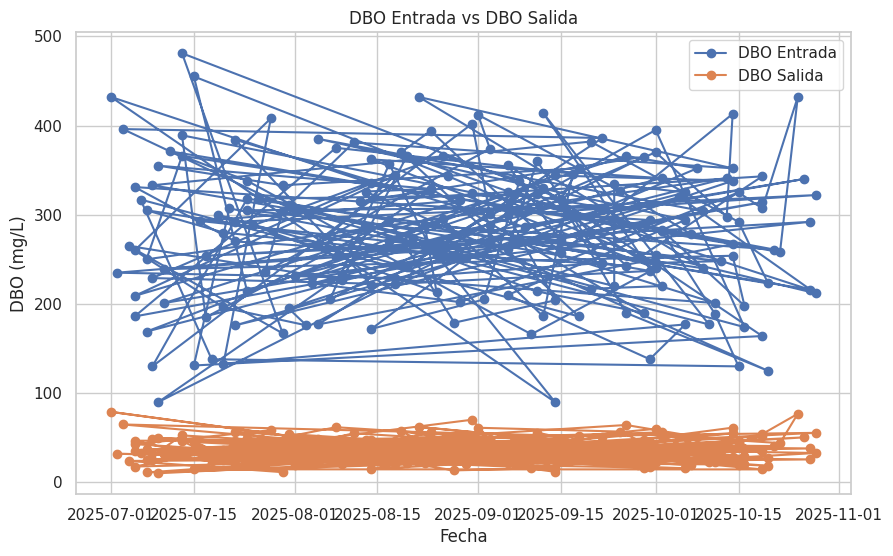

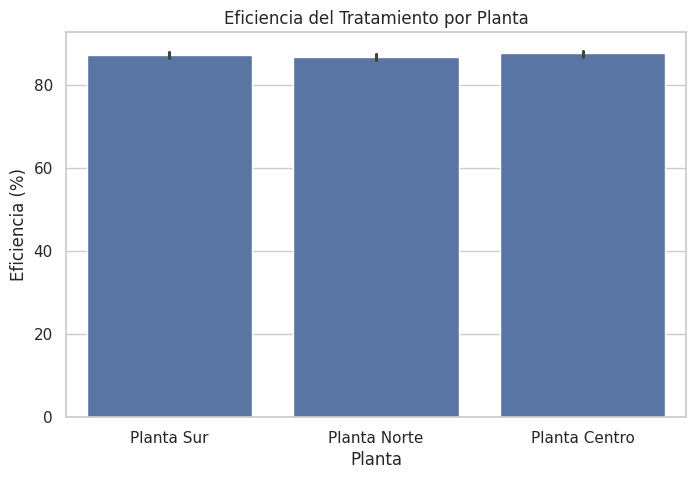

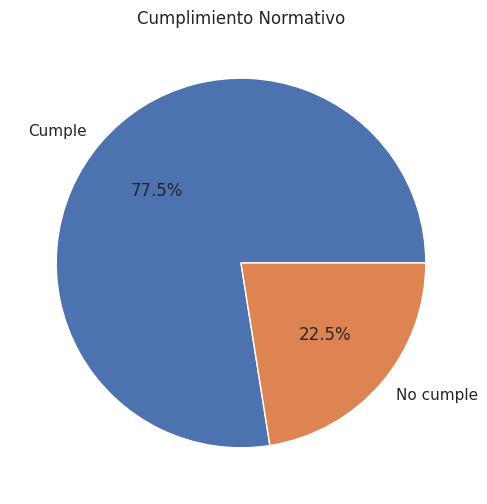

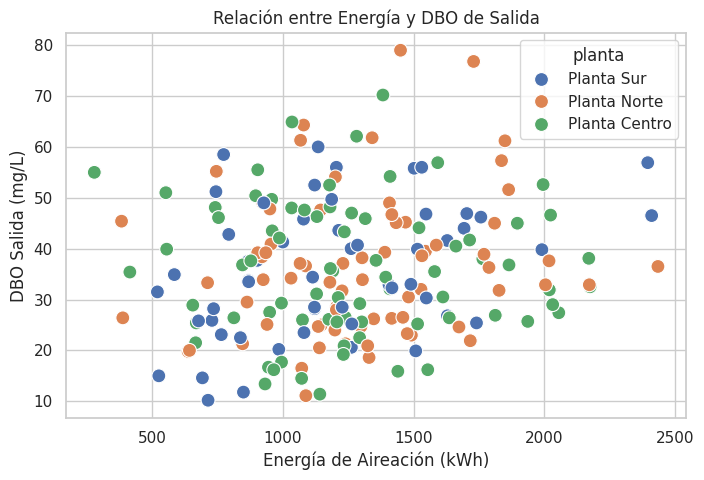

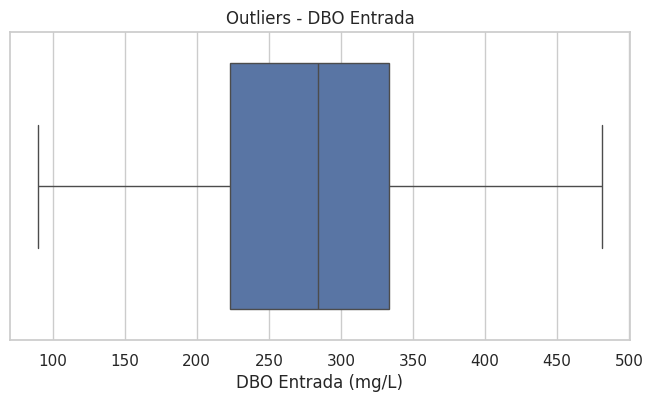

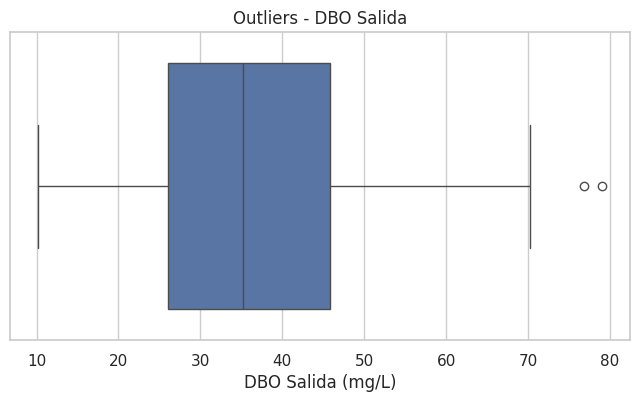

In [ ]:
# =========================================
# DASHBOARD EXPLORATORIO - VISUALIZACIONES
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Configuración visual
sns.set(style="whitegrid")

# =========================================
# GRÁFICO 1
# DBO ENTRADA VS DBO SALIDA
# =========================================

plt.figure(figsize=(10, 6))

plt.plot(
    df['fecha_registro'],
    df['DBO_entrada_mg_L'],
    marker='o',
    label='DBO Entrada'
)

plt.plot(
    df['fecha_registro'],
    df['DBO_salida_mg_L'],
    marker='o',
    label='DBO Salida'
)

plt.title('DBO Entrada vs DBO Salida')
plt.xlabel('Fecha')
plt.ylabel('DBO (mg/L)')
plt.legend()

plt.show()


# =========================================
# GRÁFICO 2
# EFICIENCIA POR PLANTA
# =========================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='planta',
    y='eficiencia_tratamiento'
)

plt.title('Eficiencia del Tratamiento por Planta')
plt.xlabel('Planta')
plt.ylabel('Eficiencia (%)')

plt.show()


# =========================================
# GRÁFICO 3
# CUMPLIMIENTO NORMATIVO
# =========================================

plt.figure(figsize=(6, 6))

cumplimiento = df['cumplimiento_norma'].value_counts()

plt.pie(
    cumplimiento,
    labels=['Cumple', 'No cumple'],
    autopct='%1.1f%%'
)

plt.title('Cumplimiento Normativo')

plt.show()


# =========================================
# GRÁFICO 4
# ENERGÍA VS DBO SALIDA
# =========================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='energia_aeracion_kWh',
    y='DBO_salida_mg_L',
    hue='planta',
    s=100
)

plt.title('Relación entre Energía y DBO de Salida')
plt.xlabel('Energía de Aireación (kWh)')
plt.ylabel('DBO Salida (mg/L)')

plt.show()


# =========================================
# GRÁFICO 5
# OUTLIERS DBO ENTRADA
# =========================================

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df['DBO_entrada_mg_L']
)

plt.title('Outliers - DBO Entrada')
plt.xlabel('DBO Entrada (mg/L)')

plt.show()


# =========================================
# GRÁFICO 6
# OUTLIERS DBO SALIDA
# =========================================

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df['DBO_salida_mg_L']
)

plt.title('Outliers - DBO Salida')
plt.xlabel('DBO Salida (mg/L)')

plt.show()


# =========================================
# DASHBOARD INTERACTIVO - PLOTLY
# =========================================

fig = px.scatter(
    df,
    x='DBO_entrada_mg_L',
    y='DBO_salida_mg_L',
    color='planta',
    size='caudal_entrada_m3_d',
    hover_data=['eficiencia_tratamiento'],
    title='Dashboard Interactivo - Plantas de Tratamiento'
)

fig.show()